## Argument Mismatch Over Matched Actions

This plot uses `matched_action_events` (all event with exact matched action name) as the denominator. Each stacked bar shows argument mismatch categories as a percentage of all matched action cases.

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_arg_mismatch_diagnostics,
    read_eval_results,
)
from utils.helpers import find_project_root


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

DIAGNOSTIC_ISSUES = [
    "Split head/modifier",
    "Preposition arg",
    "Other reason",
]

result_df = read_eval_results(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)
diagnostics_df = read_arg_mismatch_diagnostics(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
)

if "matched_action_events" not in result_df.columns:
    raise ValueError(
        "evaluation_result.csv does not contain matched_action_events. "
        "Rerun evaluation.py before drawing this figure."
    )


In [5]:
matched_counts_df = result_df[
    ["domain", "method", "model", "matched_action_events"]
].copy()

rows = []
for _, count_row in matched_counts_df.iterrows():
    domain = str(count_row["domain"])
    method = str(count_row["method"])
    model = str(count_row["model"])
    matched_action_events = int(count_row["matched_action_events"])

    group = diagnostics_df[
        (diagnostics_df["domain"].astype(str) == domain)
        & (diagnostics_df["method"].astype(str) == method)
        & (diagnostics_df["model"].astype(str) == model)
    ]
    issue_text = group["issue_text"].fillna("")
    argument_mismatch_cases = len(group)

    split_mask = issue_text.str.contains(
        "unnecessary_head_or_modifier_split", regex=False, na=False
    )
    prep_mask = issue_text.str.contains(
        "preposition_object|preposition_argument", regex=True, na=False
    ) & ~split_mask
    other_mask = ~(split_mask | prep_mask)

    category_counts = {
        "Split head/modifier": int(split_mask.sum()),
        "Preposition arg": int(prep_mask.sum()),
        "Other reason": int(other_mask.sum()),
    }
    if sum(category_counts.values()) != argument_mismatch_cases:
        raise ValueError(
            "Argument mismatch category counts do not sum to total rows for "
            f"{domain}, {method}, {model}."
        )
    if matched_action_events < argument_mismatch_cases:
        print(
            "Warning: matched_action_events is smaller than argument mismatch rows for "
            f"{domain}, {method}, {model}."
        )

    for issue, count in category_counts.items():
        rows.append(
            {
                "domain": domain,
                "method": method,
                "model": model,
                "issue": issue,
                "count": count,
                "argument_mismatch_cases": argument_mismatch_cases,
                "matched_action_events": matched_action_events,
                "share": count / matched_action_events if matched_action_events else np.nan,
            }
        )

diag_issue_matched_event_share_df = pd.DataFrame(rows).sort_values(
    ["issue", "domain", "model", "method"]
)
display(diag_issue_matched_event_share_df.head(5))


,domain,method,model,issue,count,argument_mismatch_cases,matched_action_events,share
47,cooking,nl2p_1,gemma3-12b,Other reason,426,1066,1969,0.216353
50,cooking,nl2p_1_ablation,gemma3-12b,Other reason,425,1013,2005,0.211970
53,cooking,nl2p_1_coref,gemma3-12b,Other reason,399,1069,1964,0.203157
56,cooking,nl2p_1,gemma3-27b,Other reason,315,849,1828,0.172319
59,cooking,nl2p_1_ablation,gemma3-27b,Other reason,372,807,1939,0.191851


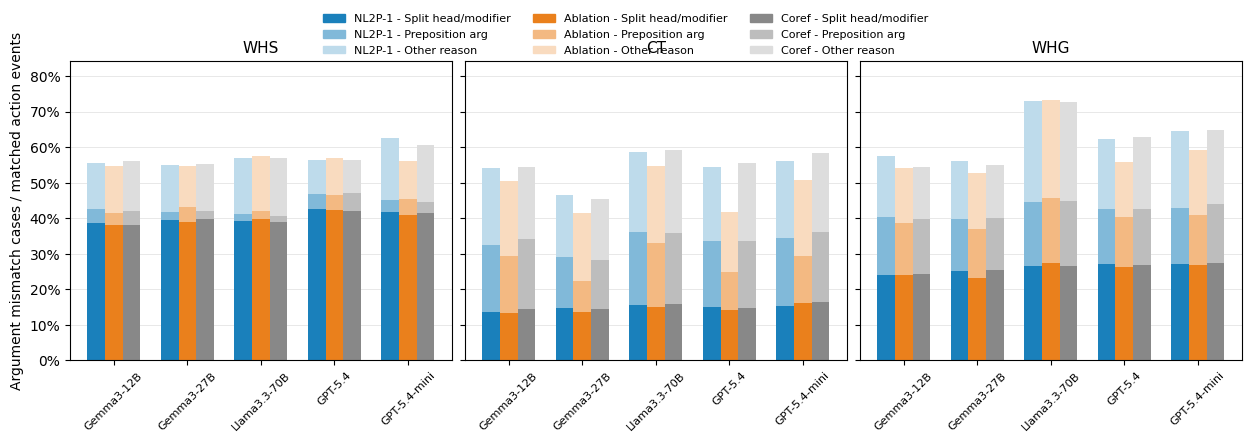

In [6]:
colors = ["#1a80bb", "#ea801c", "#888888"]
offsets = [-0.24, 0.0, 0.24]
models = [model for model in MODEL_ORDER if model in set(diag_issue_matched_event_share_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]


def lighten(hex_color, factor):
    r, g, b = (int(hex_color[i:i + 2], 16) for i in (1, 3, 5))
    r = int(r + (255 - r) * factor)
    g = int(g + (255 - g) * factor)
    b = int(b + (255 - b) * factor)
    return f"#{r:02x}{g:02x}{b:02x}"

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(DOMAIN_ORDER),
    figsize=(12.4, 4.0),
    sharey=True,
    constrained_layout=True,
)

x = np.arange(len(models))
width = 0.24
stack_max = diag_issue_matched_event_share_df.groupby(
    ["domain", "method", "model"], observed=True
)["share"].sum().max()
y_max = max(0.05, stack_max * 1.15 if pd.notna(stack_max) else 0.05)

for col_idx, domain in enumerate(DOMAIN_ORDER):
    ax = axes[col_idx]
    panel = diag_issue_matched_event_share_df[
        diag_issue_matched_event_share_df["domain"].astype(str) == domain
    ]

    for method_key, color, offset in zip(METHOD_ORDER, colors, offsets):
        bottom = np.zeros(len(models))
        for issue_idx, issue in enumerate(DIAGNOSTIC_ISSUES):
            values = []
            for model in models:
                row = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                    & (panel["issue"] == issue)
                ]
                values.append(0.0 if row.empty else float(row.iloc[0]["share"]))

            values = np.array(values)
            color_factor = [0.0, 0.45, 0.72][issue_idx]
            ax.bar(
                x + offset,
                values,
                bottom=bottom,
                width=width,
                color=color if color_factor == 0.0 else lighten(color, color_factor),
                edgecolor="none",
            )
            bottom += values

    ax.set_title(DOMAIN_LABELS[domain], fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, rotation=45, fontsize=8)
    ax.set_ylim(0.0, y_max)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.grid(axis="y", color="#d9d9d9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)
    if col_idx == 0:
        ax.set_ylabel("Argument mismatch cases / matched action events")

handles = []
for method_key, color in zip(METHOD_ORDER, colors):
    for issue_idx, issue in enumerate(DIAGNOSTIC_ISSUES):
        color_factor = [0.0, 0.45, 0.72][issue_idx]
        handles.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                color=color if color_factor == 0.0 else lighten(color, color_factor),
                label=f"{METHOD_LABELS[method_key]} - {issue}",
            )
        )

fig.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=len(METHOD_ORDER),
    frameon=False,
    fontsize=8,
)
plt.show()
